# Part 2 — Data Augmentation & Robustness

Run this **after** your Part 1 notebook. Before starting, make sure your Google Drive contains:
- `best_face_model.pth` — saved by Part 1
- `train_face_map.json`, `dev_face_map.json`, `test_face_map.json` — saved by Part 1
- `multi_faces_train.zip`, `multi_faces_dev.zip`, `multi_faces_test.zip` — saved by Part 1
- `sentiment_train.txt`, `sentiment_dev.txt`, `sentiment_test.txt`

**Goals:**
1. Apply **spatial, frequency & brightness distortions** to face crops
2. Evaluate the Part 1 model on distorted images → measure accuracy drop
3. Retrain on **mixed clean + distorted data** → show generalisation improvement

**Run cells in order from top to bottom.**

In [1]:
# CELL 1 — Mount Drive and install libraries
from google.colab import drive
drive.mount('/content/drive')

!pip install -q facenet-pytorch scikit-learn opencv-python-headless
!pip install --upgrade --force-reinstall "Pillow<10"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Using cached Pillow-9.5.0-cp312-cp312-linux_x86_64.whl
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


In [1]:
# CELL 1 — Mount Drive and install libraries
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# CELL 2 — Unzip multi-face crops and restore face maps
#
# The zips are saved to MyDrive root by Part 1 (not inside a subfolder).
# If yours are in a subfolder (e.g. MyDrive/AML/) adjust ZIP_ROOT below.
import os, glob

MULTI_TRAIN = '/content/multi_faces/multi_faces/train'
MULTI_DEV   = '/content/multi_faces/multi_faces/dev'
MULTI_TEST  = '/content/multi_faces/multi_faces/test'

# --- Try to auto-detect where the zips live on Drive ---
def find_zip(name):
    """Search MyDrive (up to 2 levels deep) for a zip with the given name."""
    patterns = [
        f'/content/drive/MyDrive/{name}',
        f'/content/drive/MyDrive/AML/{name}',
        f'/content/drive/MyDrive/**/{name}',
    ]
    for p in patterns:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0]
    return None

if not os.path.exists(MULTI_TRAIN):
    print('Unzipping multi-face crops from Drive...')
    for split in ['train', 'dev', 'test']:
        zip_name = f'multi_faces_{split}.zip'
        zip_path = find_zip(zip_name)
        if zip_path:
            print(f'  Found {zip_path}')
            ret = os.system(f'unzip -q "{zip_path}" -d /content/multi_faces/')
            if ret != 0:
                print(f'  WARNING: unzip returned non-zero exit code for {zip_name}')
        else:
            print(f'  ERROR: could not find {zip_name} on Drive — check your Drive path')
    print('Done.')
else:
    print('Multi-face crops already on disk.')

# Verify the folders exist and have crops
all_ok = True
print('\nCrop counts:')
for split, d in [('train', MULTI_TRAIN), ('dev', MULTI_DEV), ('test', MULTI_TEST)]:
    if os.path.exists(d):
        n = len([f for f in os.listdir(d) if f.endswith('.jpg')])
        print(f'  {split}: {n} crops')
        if n == 0:
            print(f'  WARNING: {d} exists but contains no .jpg files!')
            all_ok = False
    else:
        print(f'  ERROR: {d} does not exist — unzip may have failed')
        all_ok = False

if not all_ok:
    raise RuntimeError(
        'One or more face-crop folders are missing or empty.\n'
        'Check that multi_faces_train/dev/test.zip are on your Drive '
        'and that the paths above are correct.'
    )
print('\nAll crop folders OK — safe to continue.')

Multi-face crops already on disk.

Crop counts:
  train: 34291 crops
  dev: 8018 crops
  test: 8390 crops

All crop folders OK — safe to continue.


In [4]:
# CELL 3 — All imports and global config
import os, json, copy, random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, models
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LABEL_MAP   = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
NUM_CLASSES = 3

# --- Paths: set to match your Drive layout ---
# From the screenshot: best_face_model.pth, face_map JSONs → MyDrive root
#                       sentiment .txt files               → MyDrive/AML/
# Change either variable below if yours are stored differently.
DRIVE_ROOT   = '/content/drive/MyDrive'        # model weights, face maps, output plots
LABELS_ROOT  = '/content/drive/MyDrive/AML'    # sentiment_train/dev/test.txt

LABEL_TRAIN = f'{LABELS_ROOT}/sentiment_train.txt'
LABEL_DEV   = f'{LABELS_ROOT}/sentiment_dev.txt'
LABEL_TEST  = f'{LABELS_ROOT}/sentiment_test.txt'

BEST_MODEL_P1 = f'{DRIVE_ROOT}/best_face_model.pth'        # Part 1 weights
BEST_MODEL_P2 = f'{DRIVE_ROOT}/best_face_model_part2.pth'  # Part 2 retrained weights

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Imports OK.')

Device: cuda
Imports OK.


In [5]:
# CELL 4 — Load face maps
with open(f'{DRIVE_ROOT}/train_face_map.json') as f: train_face_map = json.load(f)
with open(f'{DRIVE_ROOT}/dev_face_map.json')   as f: dev_face_map   = json.load(f)
with open(f'{DRIVE_ROOT}/test_face_map.json')  as f: test_face_map  = json.load(f)

print(f'Face maps loaded — Train: {len(train_face_map)}, Dev: {len(dev_face_map)}, Test: {len(test_face_map)}')

Face maps loaded — Train: 20240, Dev: 5063, Test: 5067


In [6]:
# CELL 5 — FaceDataset (same as Part 1)

class FaceDataset(Dataset):
    """
    Each item = one face crop + its sentiment label + original image index.
    Optional `transform` is applied at __getitem__ time.
    """
    def __init__(self, face_dir, face_map, label_file, transform=None):
        self.face_dir  = face_dir
        self.transform = transform

        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]

        self.samples = []
        for orig_fname, crops in face_map.items():
            img_idx = int(orig_fname.split('.')[0])
            label   = self.labels[img_idx]
            for crop_name in crops:
                self.samples.append((crop_name, label, img_idx))
        self.samples.sort(key=lambda x: (x[2], x[0]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        crop_name, label, img_idx = self.samples[idx]
        img = Image.open(os.path.join(self.face_dir, crop_name)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, img_idx


# ---- clean baseline datasets (no augmentation, for Part 1 eval reference) ----
test_dataset_clean = FaceDataset(MULTI_TEST, test_face_map, LABEL_TEST, eval_tf)
dev_dataset_clean  = FaceDataset(MULTI_DEV,  dev_face_map,  LABEL_DEV,  eval_tf)

BATCH = 64
test_loader_clean = DataLoader(test_dataset_clean, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
dev_loader_clean  = DataLoader(dev_dataset_clean,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Clean test crops : {len(test_dataset_clean)}')
print(f'Clean dev  crops : {len(dev_dataset_clean)}')

Clean test crops : 8390
Clean dev  crops : 8018


## Section A — Distortion Definitions

We implement **three families** of distortion, each with a mild and a severe level:

| Family | What it simulates | Transforms |
|---|---|---|
| **Spatial** | Camera motion, blur, geometric warp | Gaussian blur, rotation, horizontal flip |
| **Frequency** | JPEG compression artefacts, noise | JPEG re-encode at low quality, Gaussian noise |
| **Brightness** | Lighting variation, over/underexposure | Brightness/contrast jitter, grayscale |

Each distortion transform is implemented as a `PIL → PIL` function so it can slot into any `transforms.Compose` pipeline.

In [7]:
# CELL 6 — Distortion helpers (PIL-level, drop-in for torchvision transforms)

import io
from PIL import ImageEnhance, ImageOps

# ── Spatial ─────────────────────────────────────────────────────────────────

class GaussianBlur:
    """Apply Gaussian blur (simulates camera shake / motion blur)."""
    def __init__(self, radius=2):
        self.radius = radius
    def __call__(self, img):
        return img.filter(ImageFilter.GaussianBlur(radius=self.radius))
    def __repr__(self):
        return f'GaussianBlur(r={self.radius})'


class RandomRotation:
    """Rotate by a random angle in [-max_angle, +max_angle]."""
    def __init__(self, max_angle=30):
        self.max_angle = max_angle
    def __call__(self, img):
        angle = random.uniform(-self.max_angle, self.max_angle)
        return img.rotate(angle, resample=Image.BILINEAR, expand=False)
    def __repr__(self):
        return f'RandomRotation(max={self.max_angle}°)'


class HorizontalFlip:
    """Deterministic horizontal mirror."""
    def __call__(self, img):
        return img.transpose(Image.FLIP_LEFT_RIGHT)
    def __repr__(self):
        return 'HorizontalFlip'


# ── Frequency ────────────────────────────────────────────────────────────────

class JPEGCompression:
    """Re-encode as JPEG at low quality → compression artefacts."""
    def __init__(self, quality=10):
        self.quality = quality
    def __call__(self, img):
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=self.quality)
        buf.seek(0)
        return Image.open(buf).convert('RGB')
    def __repr__(self):
        return f'JPEGCompression(q={self.quality})'


class GaussianNoise:
    """Add i.i.d. Gaussian noise to pixel values."""
    def __init__(self, sigma=25):
        self.sigma = sigma
    def __call__(self, img):
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.randn(*arr.shape) * self.sigma
        noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(noisy)
    def __repr__(self):
        return f'GaussianNoise(σ={self.sigma})'


# ── Brightness / Contrast ────────────────────────────────────────────────────

class BrightnessJitter:
    """Multiply brightness by a factor in [1-delta, 1+delta]."""
    def __init__(self, delta=0.7):
        self.delta = delta
    def __call__(self, img):
        factor = random.uniform(1 - self.delta, 1 + self.delta)
        return ImageEnhance.Brightness(img).enhance(factor)
    def __repr__(self):
        return f'BrightnessJitter(δ={self.delta})'


class ContrastJitter:
    """Multiply contrast by a factor in [1-delta, 1+delta]."""
    def __init__(self, delta=0.7):
        self.delta = delta
    def __call__(self, img):
        factor = random.uniform(1 - self.delta, 1 + self.delta)
        return ImageEnhance.Contrast(img).enhance(factor)
    def __repr__(self):
        return f'ContrastJitter(δ={self.delta})'


class Grayscale:
    """Convert to grayscale then back to RGB."""
    def __call__(self, img):
        return ImageOps.grayscale(img).convert('RGB')
    def __repr__(self):
        return 'Grayscale'


print('Distortion classes defined.')

Distortion classes defined.


In [8]:
# CELL 7 — Define distortion suites (mild & severe for each family)
#
# Each entry: (name, PIL distortion callable)
# We will build a DataLoader per distortion for isolated evaluation.

DISTORTIONS = {
    # ── Spatial ──────────────────────────────────────────────────────────────
    'spatial_blur_mild'      : GaussianBlur(radius=2),
    'spatial_blur_severe'    : GaussianBlur(radius=5),
    'spatial_rotation_mild'  : RandomRotation(max_angle=15),
    'spatial_rotation_severe': RandomRotation(max_angle=45),
    'spatial_flip'           : HorizontalFlip(),

    # ── Frequency ─────────────────────────────────────────────────────────────
    'freq_jpeg_mild'         : JPEGCompression(quality=30),
    'freq_jpeg_severe'       : JPEGCompression(quality=5),
    'freq_noise_mild'        : GaussianNoise(sigma=15),
    'freq_noise_severe'      : GaussianNoise(sigma=40),

    # ── Brightness ────────────────────────────────────────────────────────────
    'bright_jitter_mild'     : BrightnessJitter(delta=0.4),
    'bright_jitter_severe'   : BrightnessJitter(delta=0.8),
    'bright_contrast_mild'   : ContrastJitter(delta=0.4),
    'bright_contrast_severe' : ContrastJitter(delta=0.8),
    'bright_grayscale'       : Grayscale(),
}

print(f'{len(DISTORTIONS)} distortion configurations defined:')
for name, d in DISTORTIONS.items():
    print(f'  {name:35s}  {d}')

14 distortion configurations defined:
  spatial_blur_mild                    GaussianBlur(r=2)
  spatial_blur_severe                  GaussianBlur(r=5)
  spatial_rotation_mild                RandomRotation(max=15°)
  spatial_rotation_severe              RandomRotation(max=45°)
  spatial_flip                         HorizontalFlip
  freq_jpeg_mild                       JPEGCompression(q=30)
  freq_jpeg_severe                     JPEGCompression(q=5)
  freq_noise_mild                      GaussianNoise(σ=15)
  freq_noise_severe                    GaussianNoise(σ=40)
  bright_jitter_mild                   BrightnessJitter(δ=0.4)
  bright_jitter_severe                 BrightnessJitter(δ=0.8)
  bright_contrast_mild                 ContrastJitter(δ=0.4)
  bright_contrast_severe               ContrastJitter(δ=0.8)
  bright_grayscale                     Grayscale


['4873_face2.jpg', '4300_face1.jpg', '3741_face0.jpg', '3992_face0.jpg', '4487_face0.jpg', '461_face1.jpg', '3374_face0.jpg', '3438_face0.jpg', '4476_face1.jpg', '2155_face0.jpg', '3261_face1.jpg', '903_face6.jpg', '245_face0.jpg', '1391_face1.jpg', '4545_face1.jpg', '789_face1.jpg', '319_face0.jpg', '2553_face0.jpg', '719_face0.jpg', '2830_face0.jpg', '899_face7.jpg', '3929_face0.jpg', '2847_face1.jpg', '4876_face0.jpg', '1276_face3.jpg', '3879_face0.jpg', '3457_face0.jpg', '4496_face1.jpg', '952_face0.jpg', '1982_face0.jpg', '2208_face0.jpg', '4338_face0.jpg', '4120_face0.jpg', '4089_face0.jpg', '802_face1.jpg', '5020_face1.jpg', '1609_face1.jpg', '869_face0.jpg', '1690_face1.jpg', '2082_face0.jpg', '769_face0.jpg', '4103_face1.jpg', '2502_face0.jpg', '1021_face0.jpg', '1801_face0.jpg', '2962_face2.jpg', '1747_face0.jpg', '4491_face1.jpg', '4883_face0.jpg', '1111_face0.jpg', '1135_face0.jpg', '3849_face2.jpg', '3920_face0.jpg', '2474_face0.jpg', '2927_face0.jpg', '3435_face0.jpg', '4

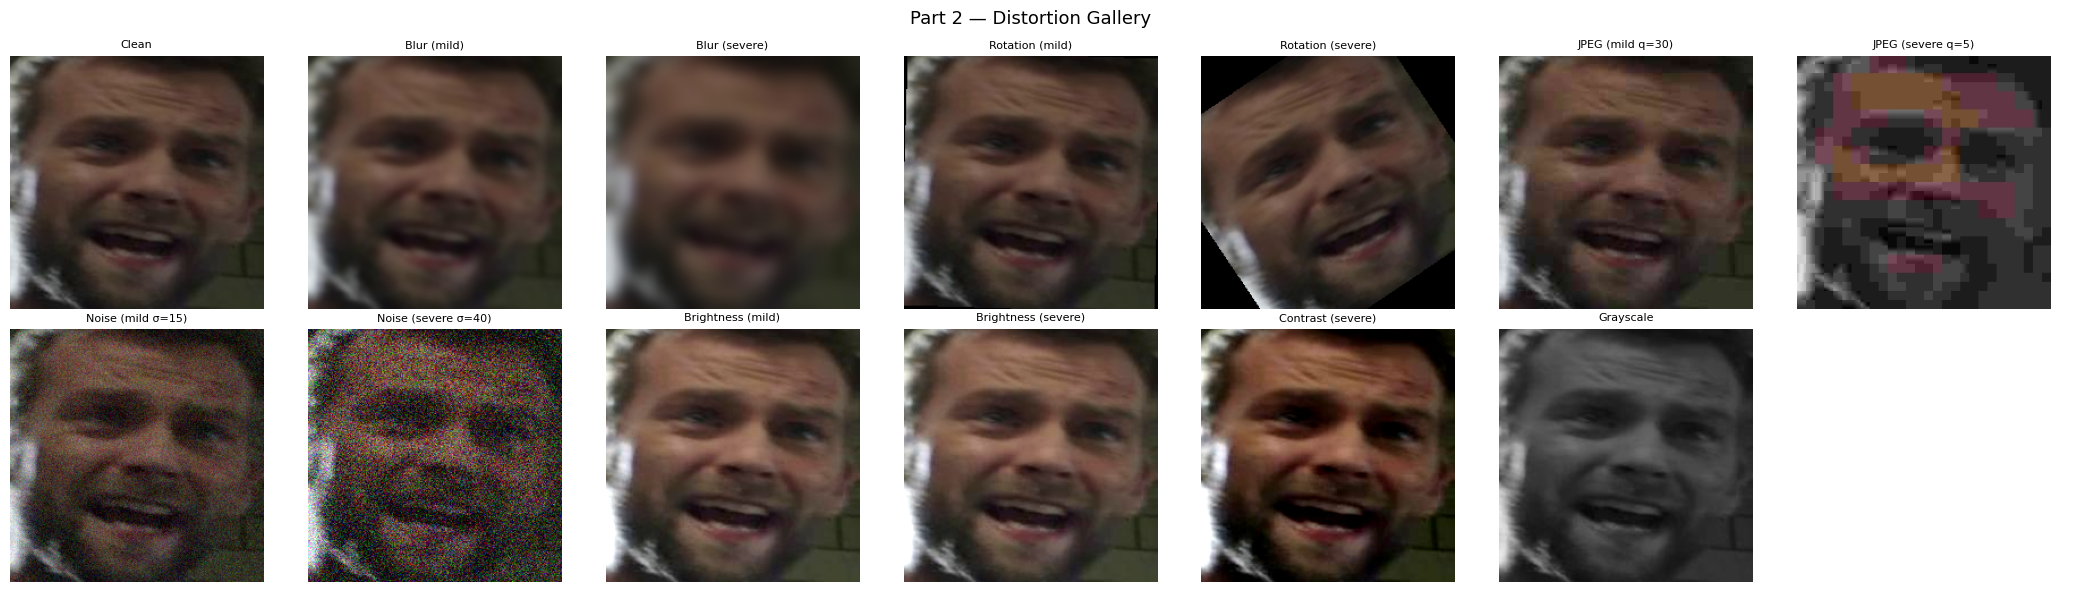

Gallery saved to Drive.


In [9]:
# CELL 8 — Visualise distortions on a sample image
#
# Shows a grid so you can visually inspect what each distortion looks like.
# This cell is for intuition only — skip to Cell 9 to begin evaluation.
import os

MULTI_TEST = '/content/multi_faces/multi_faces/test'
print(os.listdir(MULTI_TEST))
# Pick the first test crop for illustration
sample_img_key  = list(test_face_map.keys())[0]
sample_crop     = test_face_map[sample_img_key][0]
sample_pil      = Image.open(os.path.join(MULTI_TEST, sample_crop)).convert('RGB').resize((224, 224))

# Pick a representative subset to display
SHOW = [
    ('Clean',                  sample_pil),
    ('Blur (mild)',            DISTORTIONS['spatial_blur_mild'](sample_pil)),
    ('Blur (severe)',          DISTORTIONS['spatial_blur_severe'](sample_pil)),
    ('Rotation (mild)',        DISTORTIONS['spatial_rotation_mild'](sample_pil)),
    ('Rotation (severe)',      DISTORTIONS['spatial_rotation_severe'](sample_pil)),
    ('JPEG (mild q=30)',       DISTORTIONS['freq_jpeg_mild'](sample_pil)),
    ('JPEG (severe q=5)',      DISTORTIONS['freq_jpeg_severe'](sample_pil)),
    ('Noise (mild σ=15)',      DISTORTIONS['freq_noise_mild'](sample_pil)),
    ('Noise (severe σ=40)',    DISTORTIONS['freq_noise_severe'](sample_pil)),
    ('Brightness (mild)',      DISTORTIONS['bright_jitter_mild'](sample_pil)),
    ('Brightness (severe)',    DISTORTIONS['bright_jitter_severe'](sample_pil)),
    ('Contrast (severe)',      DISTORTIONS['bright_contrast_severe'](sample_pil)),
    ('Grayscale',              DISTORTIONS['bright_grayscale'](sample_pil)),
]

cols = 7
rows = (len(SHOW) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

for ax, (title, img) in zip(axes.flatten(), SHOW):
    ax.imshow(img)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

for ax in axes.flatten()[len(SHOW):]:
    ax.axis('off')

plt.suptitle('Part 2 — Distortion Gallery', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/distortion_gallery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gallery saved to Drive.')

## Section B — Evaluate Part 1 Model on Distorted Images

In [10]:
# CELL 9 — Load the Part 1 model weights

def build_resnet18(num_classes=3):
    m = models.resnet18(weights='IMAGENET1K_V1')
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer4.parameters():
        p.requires_grad = True
    m.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return m


model_p1 = build_resnet18(NUM_CLASSES).to(device)
model_p1.load_state_dict(torch.load(BEST_MODEL_P1, map_location=device))
model_p1.eval()
print(f'Part 1 model loaded from {BEST_MODEL_P1}')

Part 1 model loaded from /content/drive/MyDrive/best_face_model.pth


In [11]:
# CELL 10 — Evaluation helper (same aggregate-face logic as Part 1)

@torch.no_grad()
def evaluate(model, loader, criterion=None, aggregate_faces=True):
    """
    Returns (loss, accuracy, predictions, labels).
    If criterion is None, loss is returned as 0.0.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    all_logits, all_labels, all_idx = [], [], []

    for imgs, labels, img_idx in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())
        all_idx.append(img_idx)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    all_idx    = torch.cat(all_idx)
    avg_loss   = total_loss / len(loader.dataset)

    if aggregate_faces:
        softmax = torch.softmax(all_logits, dim=1)
        preds, labs = [], []
        for img_i in all_idx.unique().tolist():
            mask     = all_idx == img_i
            avg_prob = softmax[mask].mean(0)
            preds.append(avg_prob.argmax().item())
            labs.append(all_labels[mask][0].item())
    else:
        preds = all_logits.argmax(1).tolist()
        labs  = all_labels.tolist()

    acc = sum(p == l for p, l in zip(preds, labs)) / len(labs)
    return avg_loss, acc, preds, labs


print('Evaluation function defined.')

Evaluation function defined.


In [12]:
# CELL 11 — Baseline: evaluate Part 1 model on CLEAN test set

_, clean_acc, clean_preds, clean_labs = evaluate(model_p1, test_loader_clean)
clean_macro_f1 = f1_score(clean_labs, clean_preds, average='macro')

print('=' * 55)
print('Part 1 Model — CLEAN Test Set (Baseline)')
print('=' * 55)
print(f'Accuracy  : {clean_acc:.4f}  ({clean_acc*100:.2f}%)')
print(f'Macro F1  : {clean_macro_f1:.4f}')

Part 1 Model — CLEAN Test Set (Baseline)
Accuracy  : 0.3471  (34.71%)
Macro F1  : 0.2736


In [13]:
# CELL 12 — Evaluate Part 1 model on each distorted test set
#
# For each distortion we build a transform pipeline that:
#   1. Resizes to 224×224
#   2. Applies the distortion (PIL level)
#   3. Converts to tensor and normalises
# This mirrors the clean eval_tf but adds the distortion in the middle.

def make_distorted_tf(distortion_fn):
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(distortion_fn),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])


distortion_results = {'clean': {'acc': clean_acc, 'f1': clean_macro_f1, 'drop': 0.0}}

print(f"{'Distortion':<35s}  {'Acc':>6s}  {'MacroF1':>7s}  {'AccDrop':>8s}")
print('-' * 65)
print(f"{'clean (baseline)':<35s}  {clean_acc:6.4f}  {clean_macro_f1:7.4f}  {'—':>8s}")

for dist_name, dist_fn in DISTORTIONS.items():
    tf      = make_distorted_tf(dist_fn)
    ds      = FaceDataset(MULTI_TEST, test_face_map, LABEL_TEST, tf)
    loader  = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
    _, acc, preds, labs = evaluate(model_p1, loader)
    mf1  = f1_score(labs, preds, average='macro')
    drop = clean_acc - acc
    distortion_results[dist_name] = {'acc': acc, 'f1': mf1, 'drop': drop}
    print(f"{dist_name:<35s}  {acc:6.4f}  {mf1:7.4f}  {drop:+8.4f}")

print('\nDone. (Negative drop = distortion improved accuracy, unlikely but possible due to flip/jitter randomness.)')

Distortion                              Acc  MacroF1   AccDrop
-----------------------------------------------------------------
clean (baseline)                     0.3471   0.2736         —
spatial_blur_mild                    0.3057   0.2379   +0.0414
spatial_blur_severe                  0.2585   0.1420   +0.0886
spatial_rotation_mild                0.3458   0.2726   +0.0014
spatial_rotation_severe              0.3310   0.2631   +0.0162
spatial_flip                         0.3491   0.2743   -0.0020
freq_jpeg_mild                       0.3124   0.2467   +0.0347
freq_jpeg_severe                     0.2562   0.1360   +0.0910
freq_noise_mild                      0.2714   0.1858   +0.0758
freq_noise_severe                    0.2562   0.1360   +0.0910
bright_jitter_mild                   0.3470   0.2738   +0.0002
bright_jitter_severe                 0.3389   0.2692   +0.0083
bright_contrast_mild                 0.3481   0.2745   -0.0010
bright_contrast_severe               0.3391   0.2688

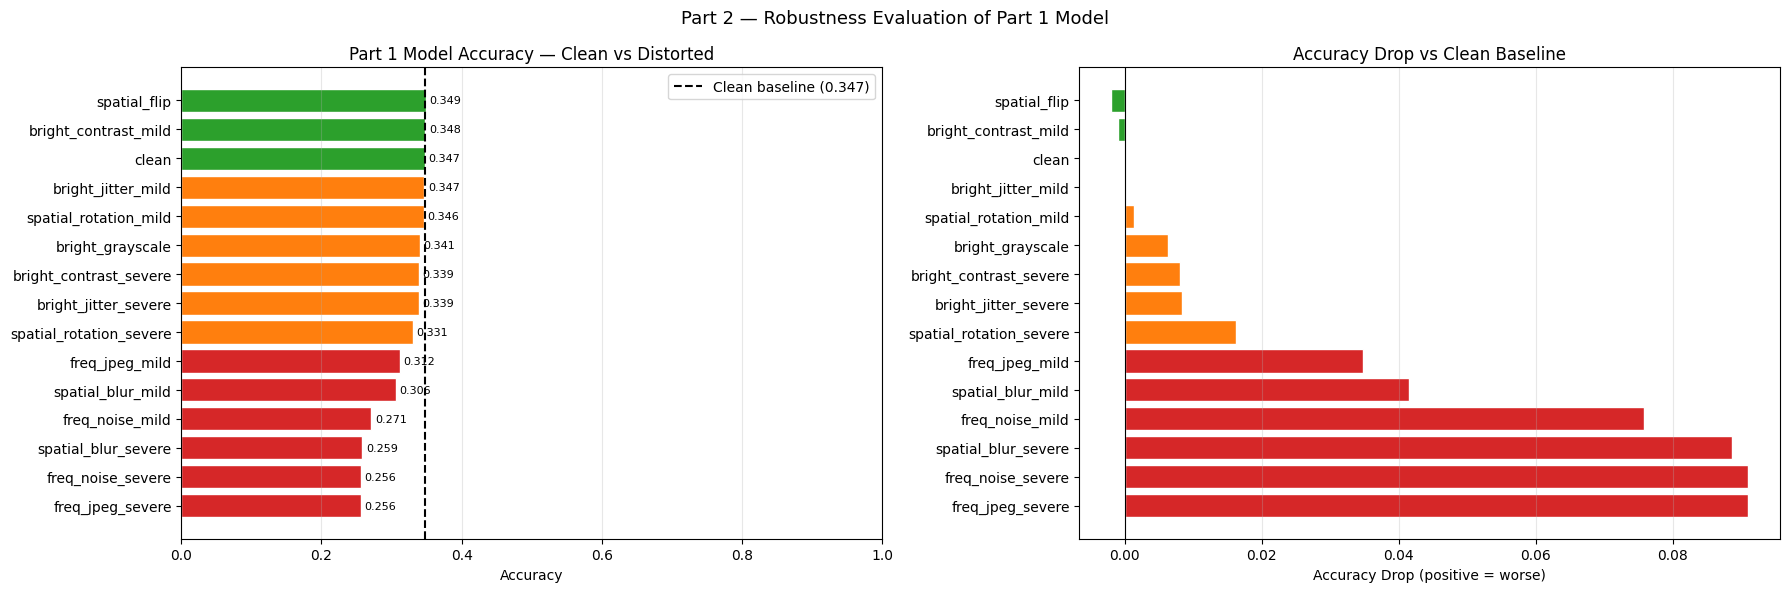

Saved to Drive.


In [14]:
# CELL 13 — Plot accuracy drop chart (Part 1 model on distorted data)

names = list(distortion_results.keys())
accs  = [distortion_results[n]['acc']  for n in names]
drops = [distortion_results[n]['drop'] for n in names]

# Sort by severity of drop (descending)
order  = sorted(range(len(names)), key=lambda i: drops[i], reverse=True)
names  = [names[i]  for i in order]
accs   = [accs[i]   for i in order]
drops  = [drops[i]  for i in order]

colors = ['#d62728' if d > 0.02 else '#ff7f0e' if d > 0 else '#2ca02c' for d in drops]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: accuracy per distortion
ax = axes[0]
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(clean_acc, color='black', linestyle='--', linewidth=1.5, label=f'Clean baseline ({clean_acc:.3f})')
ax.set_xlabel('Accuracy')
ax.set_title('Part 1 Model Accuracy — Clean vs Distorted')
ax.legend()
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, accs):
    ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center', fontsize=8)

# Right: accuracy drop
ax2 = axes[1]
ax2.barh(names, drops, color=colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Accuracy Drop (positive = worse)')
ax2.set_title('Accuracy Drop vs Clean Baseline')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Part 2 — Robustness Evaluation of Part 1 Model', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/robustness_eval_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [15]:
# CELL 14 — Per-family summary

families = {
    'Spatial'    : [k for k in distortion_results if k.startswith('spatial')],
    'Frequency'  : [k for k in distortion_results if k.startswith('freq')],
    'Brightness' : [k for k in distortion_results if k.startswith('bright')],
}

print('=' * 55)
print('Part 1 Model — Accuracy Drop by Distortion Family')
print('=' * 55)
for family, keys in families.items():
    drops_f = [distortion_results[k]['drop'] for k in keys]
    print(f'\n{family}:')
    for k, d in zip(keys, drops_f):
        acc = distortion_results[k]['acc']
        print(f'  {k:<35s}  acc={acc:.4f}  drop={d:+.4f}')
    print(f'  → Mean drop: {np.mean(drops_f):+.4f}   Worst drop: {max(drops_f):+.4f}')

Part 1 Model — Accuracy Drop by Distortion Family

Spatial:
  spatial_blur_mild                    acc=0.3057  drop=+0.0414
  spatial_blur_severe                  acc=0.2585  drop=+0.0886
  spatial_rotation_mild                acc=0.3458  drop=+0.0014
  spatial_rotation_severe              acc=0.3310  drop=+0.0162
  spatial_flip                         acc=0.3491  drop=-0.0020
  → Mean drop: +0.0291   Worst drop: +0.0886

Frequency:
  freq_jpeg_mild                       acc=0.3124  drop=+0.0347
  freq_jpeg_severe                     acc=0.2562  drop=+0.0910
  freq_noise_mild                      acc=0.2714  drop=+0.0758
  freq_noise_severe                    acc=0.2562  drop=+0.0910
  → Mean drop: +0.0731   Worst drop: +0.0910

Brightness:
  bright_jitter_mild                   acc=0.3470  drop=+0.0002
  bright_jitter_severe                 acc=0.3389  drop=+0.0083
  bright_contrast_mild                 acc=0.3481  drop=-0.0010
  bright_contrast_severe               acc=0.3391  drop=+

## Section C — Retrain on Mixed Clean + Distorted Data

Strategy:
- Keep all clean training crops
- For each clean training crop, generate **one augmented copy** drawn randomly from the full distortion set
- This doubles the training set size while exposing the model to all distortion types
- Train with the same ResNet-18 architecture and hyperparameters as Part 1
- Compare the retrained model's accuracy on each distorted test set vs the Part 1 model

In [16]:
# CELL 15 — AugmentedFaceDataset: randomly applies one distortion per item

class AugmentedFaceDataset(Dataset):
    """
    Like FaceDataset but applies one randomly-chosen distortion at __getitem__ time.
    Produces one augmented copy of each sample per epoch.
    """
    def __init__(self, face_dir, face_map, label_file, distortion_pool, base_tf):
        """
        distortion_pool : list of callable PIL→PIL distortions
        base_tf         : transforms.Compose applied AFTER distortion (resize/normalise)
        """
        self.face_dir        = face_dir
        self.distortion_pool = distortion_pool
        self.base_tf         = base_tf

        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]

        self.samples = []
        for orig_fname, crops in face_map.items():
            img_idx = int(orig_fname.split('.')[0])
            label   = self.labels[img_idx]
            for crop_name in crops:
                self.samples.append((crop_name, label, img_idx))
        self.samples.sort(key=lambda x: (x[2], x[0]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        crop_name, label, img_idx = self.samples[idx]
        img = Image.open(os.path.join(self.face_dir, crop_name)).convert('RGB')
        img = img.resize((224, 224))
        # Apply one random distortion from the pool
        dist_fn = random.choice(self.distortion_pool)
        img = dist_fn(img)
        if self.base_tf:
            img = self.base_tf(img)
        return img, label, img_idx


# Transforms applied AFTER distortion (only tensor conversion + normalise;
# resize already handled inside AugmentedFaceDataset)
post_distort_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Clean training transform (same as Part 1 — light flip/rotation/colour jitter)
clean_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

distortion_pool = list(DISTORTIONS.values())

# Build clean and augmented datasets
clean_train_ds  = FaceDataset(MULTI_TRAIN, train_face_map, LABEL_TRAIN, clean_train_tf)
aug_train_ds    = AugmentedFaceDataset(
    MULTI_TRAIN, train_face_map, LABEL_TRAIN,
    distortion_pool=distortion_pool,
    base_tf=post_distort_tf
)

# Concatenate: each epoch sees both clean AND augmented crops
mixed_train_ds = ConcatDataset([clean_train_ds, aug_train_ds])

BATCH = 64
mixed_train_loader = DataLoader(mixed_train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader_clean   = DataLoader(dev_dataset_clean, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Clean train crops     : {len(clean_train_ds)}')
print(f'Augmented train crops : {len(aug_train_ds)}')
print(f'Mixed total           : {len(mixed_train_ds)}')

Clean train crops     : 34291
Augmented train crops : 34291
Mixed total           : 68582


In [17]:
# CELL 16 — Build fresh model and training components for Part 2

model_p2 = build_resnet18(NUM_CLASSES).to(device)

# Weighted cross-entropy (recompute from clean train labels)
all_train_labels = [s[1] for s in clean_train_ds.samples]
class_counts     = Counter(all_train_labels)
total_n          = len(all_train_labels)
class_weights    = torch.tensor(
    [total_n / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)

print('Training label distribution:')
for i, name in LABEL_MAP.items():
    c = class_counts[i]
    print(f'  {name} ({i}): {c}  ({100*c/total_n:.1f}%)')
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

criterion_p2 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_p2.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.5, patience=3, verbose=True
)

Training label distribution:
  Neutral (0): 11996  (35.0%)
  Negative (1): 12722  (37.1%)
  Positive (2): 9573  (27.9%)
Class weights: [0.953 0.898 1.194]


In [18]:
# CELL 17 — Training loop (Part 2 model — mixed clean + distorted)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


NUM_EPOCHS = 20
PATIENCE   = 5

history_p2    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
no_improve    = 0

print(f'Training Part 2 model on MIXED data  (up to {NUM_EPOCHS} epochs, early stop after {PATIENCE})')
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc       = train_one_epoch(model_p2, mixed_train_loader, criterion_p2, optimizer_p2)
    vl_loss, vl_acc, _, _ = evaluate(model_p2, dev_loader_clean, criterion_p2)
    scheduler_p2.step(vl_loss)

    history_p2['train_loss'].append(tr_loss)
    history_p2['train_acc'].append(tr_acc)
    history_p2['val_loss'].append(vl_loss)
    history_p2['val_acc'].append(vl_acc)

    tag = ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        no_improve    = 0
        torch.save(model_p2.state_dict(), BEST_MODEL_P2)
        tag = '  <- best saved'
    else:
        no_improve += 1

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'Train loss {tr_loss:.4f}  acc {tr_acc:.3f} | '
          f'Val loss {vl_loss:.4f}  acc {vl_acc:.3f}{tag}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print('Training complete.')

Training Part 2 model on MIXED data  (up to 20 epochs, early stop after 5)
------------------------------------------------------------------------
Ep 01/20 | Train loss 1.1011  acc 0.345 | Val loss 1.1012  acc 0.350  <- best saved
Ep 02/20 | Train loss 1.0979  acc 0.358 | Val loss 1.0987  acc 0.367  <- best saved
Ep 03/20 | Train loss 1.0968  acc 0.372 | Val loss 1.0979  acc 0.376  <- best saved
Ep 04/20 | Train loss 1.0957  acc 0.369 | Val loss 1.1102  acc 0.353
Ep 05/20 | Train loss 1.0948  acc 0.368 | Val loss 1.1024  acc 0.355
Ep 06/20 | Train loss 1.0935  acc 0.379 | Val loss 1.1026  acc 0.371
Ep 07/20 | Train loss 1.0922  acc 0.384 | Val loss 1.1070  acc 0.349
Ep 08/20 | Train loss 1.0896  acc 0.393 | Val loss 1.1065  acc 0.353
Early stopping at epoch 8.
Training complete.


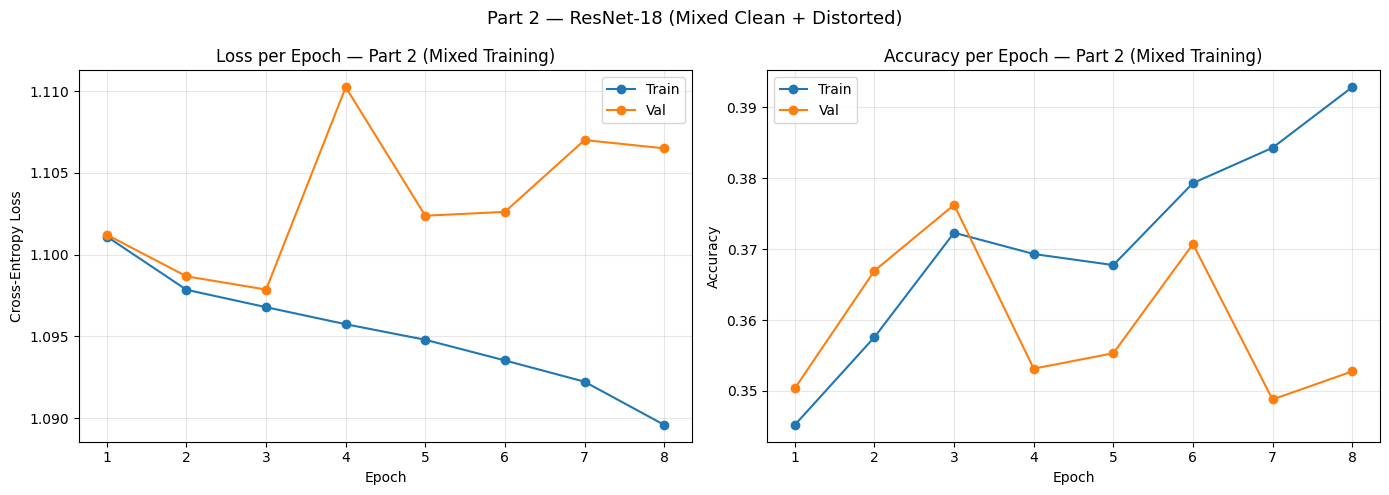

Saved to Drive.


In [19]:
# CELL 18 — Plot Part 2 training curves

ep = range(1, len(history_p2['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, history_p2['train_loss'], 'o-', label='Train')
ax1.plot(ep, history_p2['val_loss'],   'o-', label='Val')
ax1.set_title('Loss per Epoch — Part 2 (Mixed Training)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history_p2['train_acc'], 'o-', label='Train')
ax2.plot(ep, history_p2['val_acc'],   'o-', label='Val')
ax2.set_title('Accuracy per Epoch — Part 2 (Mixed Training)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Part 2 — ResNet-18 (Mixed Clean + Distorted)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/training_curves_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [20]:
# CELL 19 — Load best Part 2 weights and evaluate on clean test set

model_p2.load_state_dict(torch.load(BEST_MODEL_P2, map_location=device))
model_p2.eval()
print('Best Part 2 model loaded.')

_, p2_clean_acc, p2_clean_preds, p2_clean_labs = evaluate(model_p2, test_loader_clean)
p2_clean_f1 = f1_score(p2_clean_labs, p2_clean_preds, average='macro')

print('\n' + '=' * 55)
print('Part 2 Model — CLEAN Test Set')
print('=' * 55)
print(f'Accuracy  : {p2_clean_acc:.4f}  (Part 1 was {clean_acc:.4f})')
print(f'Macro F1  : {p2_clean_f1:.4f}  (Part 1 was {clean_macro_f1:.4f})')

Best Part 2 model loaded.

Part 2 Model — CLEAN Test Set
Accuracy  : 0.3694  (Part 1 was 0.3471)
Macro F1  : 0.3038  (Part 1 was 0.2736)


In [21]:
# CELL 20 — Evaluate Part 2 model on every distorted test set

p2_results = {'clean': {'acc': p2_clean_acc, 'f1': p2_clean_f1, 'drop': 0.0}}

print(f"{'Distortion':<35s}  {'P1 Acc':>7s}  {'P2 Acc':>7s}  {'Δ Acc':>8s}")
print('-' * 65)
print(f"{'clean (baseline)':<35s}  {clean_acc:7.4f}  {p2_clean_acc:7.4f}  {p2_clean_acc - clean_acc:+8.4f}")

for dist_name, dist_fn in DISTORTIONS.items():
    tf     = make_distorted_tf(dist_fn)
    ds     = FaceDataset(MULTI_TEST, test_face_map, LABEL_TEST, tf)
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
    _, acc, preds, labs = evaluate(model_p2, loader)
    mf1  = f1_score(labs, preds, average='macro')
    drop = p2_clean_acc - acc
    p2_results[dist_name] = {'acc': acc, 'f1': mf1, 'drop': drop}

    p1_acc  = distortion_results[dist_name]['acc']
    delta   = acc - p1_acc
    print(f"{dist_name:<35s}  {p1_acc:7.4f}  {acc:7.4f}  {delta:+8.4f}")

print('\n(Δ Acc = Part 2 accuracy − Part 1 accuracy on same distorted set; positive = improvement)')

Distortion                            P1 Acc   P2 Acc     Δ Acc
-----------------------------------------------------------------
clean (baseline)                      0.3471   0.3694   +0.0223
spatial_blur_mild                     0.3057   0.3659   +0.0602
spatial_blur_severe                   0.2585   0.3318   +0.0732
spatial_rotation_mild                 0.3458   0.3710   +0.0253
spatial_rotation_severe               0.3310   0.3665   +0.0355
spatial_flip                          0.3491   0.3764   +0.0272
freq_jpeg_mild                        0.3124   0.3396   +0.0272
freq_jpeg_severe                      0.2562   0.2574   +0.0012
freq_noise_mild                       0.2714   0.3160   +0.0446
freq_noise_severe                     0.2562   0.2566   +0.0004
bright_jitter_mild                    0.3470   0.3777   +0.0308
bright_jitter_severe                  0.3389   0.3746   +0.0357
bright_contrast_mild                  0.3481   0.3730   +0.0249
bright_contrast_severe                

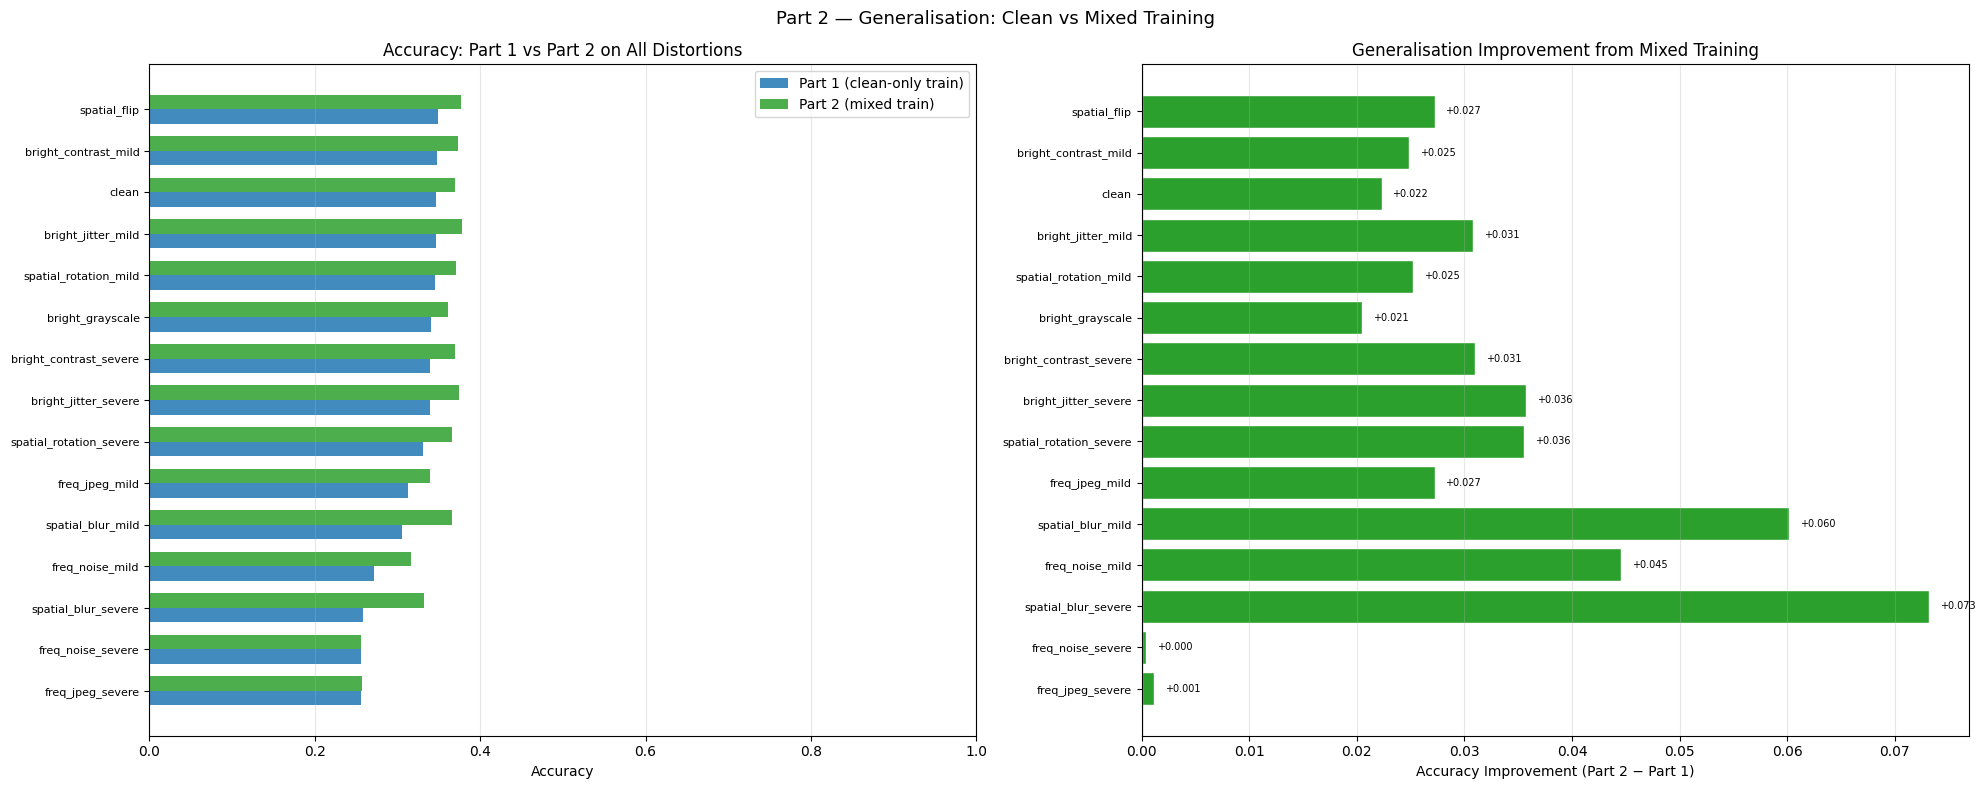

Saved to Drive.


In [22]:
# CELL 21 — Side-by-side comparison plot: Part 1 vs Part 2 on all distortions

all_names  = ['clean'] + list(DISTORTIONS.keys())
p1_accs    = [distortion_results[n]['acc'] for n in all_names]
p2_accs    = [p2_results[n]['acc']         for n in all_names]
deltas     = [p2_accs[i] - p1_accs[i]     for i in range(len(all_names))]

# Sort by Part 1 accuracy (ascending — worst first)
order     = sorted(range(len(all_names)), key=lambda i: p1_accs[i])
all_names = [all_names[i] for i in order]
p1_accs   = [p1_accs[i]  for i in order]
p2_accs   = [p2_accs[i]  for i in order]
deltas    = [deltas[i]    for i in order]

y     = np.arange(len(all_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: grouped bars
ax = axes[0]
ax.barh(y - width/2, p1_accs, width, label='Part 1 (clean-only train)', color='#1f77b4', alpha=0.85)
ax.barh(y + width/2, p2_accs, width, label='Part 2 (mixed train)',        color='#2ca02c', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(all_names, fontsize=8)
ax.set_xlabel('Accuracy')
ax.set_title('Accuracy: Part 1 vs Part 2 on All Distortions')
ax.legend()
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Right: improvement (Δ)
ax2 = axes[1]
bar_colors = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
ax2.barh(y, deltas, color=bar_colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels(all_names, fontsize=8)
ax2.set_xlabel('Accuracy Improvement (Part 2 − Part 1)')
ax2.set_title('Generalisation Improvement from Mixed Training')
ax2.grid(axis='x', alpha=0.3)
for bar, d in zip(ax2.patches, deltas):
    ax2.text(d + 0.001 if d >= 0 else d - 0.001, bar.get_y() + bar.get_height() / 2,
             f'{d:+.3f}', va='center', ha='left' if d >= 0 else 'right', fontsize=7)

plt.suptitle('Part 2 — Generalisation: Clean vs Mixed Training', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/generalisation_comparison_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

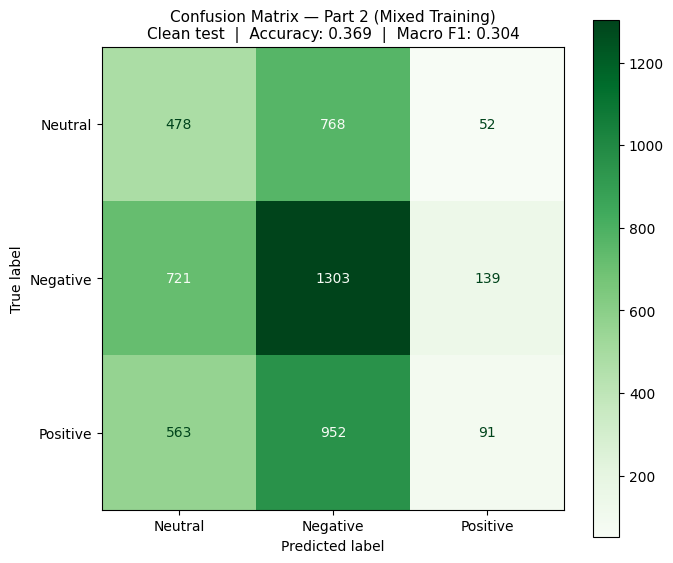

Saved to Drive.


In [23]:
# CELL 22 — Confusion matrix: Part 2 model on clean test set

cm = confusion_matrix(p2_clean_labs, p2_clean_preds)
class_names = [LABEL_MAP[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title(
    f'Confusion Matrix — Part 2 (Mixed Training)\n'
    f'Clean test  |  Accuracy: {p2_clean_acc:.3f}  |  Macro F1: {p2_clean_f1:.3f}',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/confusion_matrix_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [24]:
# CELL 23 — Detailed classification report: Part 2 model on clean test set

print('=' * 55)
print('Part 2 Model — Clean Test Classification Report')
print('=' * 55)
print(classification_report(
    p2_clean_labs, p2_clean_preds,
    target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]
))

Part 2 Model — Clean Test Classification Report
              precision    recall  f1-score   support

     Neutral       0.27      0.37      0.31      1298
    Negative       0.43      0.60      0.50      2163
    Positive       0.32      0.06      0.10      1606

    accuracy                           0.37      5067
   macro avg       0.34      0.34      0.30      5067
weighted avg       0.36      0.37      0.33      5067



In [25]:
# CELL 24 — Per-family robustness summary: Part 1 vs Part 2

families = {
    'Spatial'    : [k for k in DISTORTIONS if k.startswith('spatial')],
    'Frequency'  : [k for k in DISTORTIONS if k.startswith('freq')],
    'Brightness' : [k for k in DISTORTIONS if k.startswith('bright')],
}

print('=' * 72)
print('Per-Family Robustness Summary')
print(f"{'Family / Distortion':<38s}  {'P1 Acc':>7s}  {'P2 Acc':>7s}  {'Δ Acc':>8s}")
print('=' * 72)

for family, keys in families.items():
    print(f'\n{family}:')
    p1_f, p2_f = [], []
    for k in keys:
        p1a = distortion_results[k]['acc']
        p2a = p2_results[k]['acc']
        delta = p2a - p1a
        p1_f.append(p1a); p2_f.append(p2a)
        marker = '✓' if delta > 0 else '✗'
        print(f'  {marker} {k:<36s}  {p1a:7.4f}  {p2a:7.4f}  {delta:+8.4f}')
    mean_delta = np.mean([p2 - p1 for p1, p2 in zip(p1_f, p2_f)])
    print(f'  → Mean Δ across {family}: {mean_delta:+.4f}')

# Overall
all_keys  = list(DISTORTIONS.keys())
all_delta = [p2_results[k]['acc'] - distortion_results[k]['acc'] for k in all_keys]
print(f'\nOverall mean Δ accuracy (all distortions): {np.mean(all_delta):+.4f}')
print(f'Distortions improved: {sum(d > 0 for d in all_delta)}/{len(all_delta)}')

Per-Family Robustness Summary
Family / Distortion                      P1 Acc   P2 Acc     Δ Acc

Spatial:
  ✓ spatial_blur_mild                      0.3057   0.3659   +0.0602
  ✓ spatial_blur_severe                    0.2585   0.3318   +0.0732
  ✓ spatial_rotation_mild                  0.3458   0.3710   +0.0253
  ✓ spatial_rotation_severe                0.3310   0.3665   +0.0355
  ✓ spatial_flip                           0.3491   0.3764   +0.0272
  → Mean Δ across Spatial: +0.0443

Frequency:
  ✓ freq_jpeg_mild                         0.3124   0.3396   +0.0272
  ✓ freq_jpeg_severe                       0.2562   0.2574   +0.0012
  ✓ freq_noise_mild                        0.2714   0.3160   +0.0446
  ✓ freq_noise_severe                      0.2562   0.2566   +0.0004
  → Mean Δ across Frequency: +0.0184

Brightness:
  ✓ bright_jitter_mild                     0.3470   0.3777   +0.0308
  ✓ bright_jitter_severe                   0.3389   0.3746   +0.0357
  ✓ bright_contrast_mild             

In [28]:
# CELL 25 — Final summary

print('=' * 60)
print('PART 2 — DATA AUGMENTATION & ROBUSTNESS — FINAL SUMMARY')
print('=' * 60)

print('\n── Model Info ')
print(f'  Architecture  : ResNet-18 (fine-tuned, same as Part 1)')
print(f'  Part 2 data   : clean train crops + 1× randomly-distorted copy')
print(f'  Distortions   : {len(DISTORTIONS)} configs across spatial, frequency & brightness')

print('\n── Clean Test Performance ')
print(f'  Part 1 (clean-only)  Acc: {clean_acc:.4f}   Macro F1: {clean_macro_f1:.4f}')
print(f'  Part 2 (mixed)       Acc: {p2_clean_acc:.4f}   Macro F1: {p2_clean_f1:.4f}')
print(f'  Δ clean accuracy     : {p2_clean_acc - clean_acc:+.4f}')

print('\n── Robustness on Distorted Test Sets' )
print(f'  Part 1 mean acc  : {np.mean([distortion_results[k]["acc"] for k in DISTORTIONS]):.4f}')
print(f'  Part 2 mean acc  : {np.mean([p2_results[k]["acc"]         for k in DISTORTIONS]):.4f}')
print(f'  Mean improvement : {np.mean(all_delta):+.4f}')
print(f'  Improved in      : {sum(d > 0 for d in all_delta)}/{len(all_delta)} distortions')

print('\n── Files saved to Drive ')
print(f'  best_face_model_part2.pth        <- retrained weights')
print(f'  distortion_gallery.png           <- visual overview of distortions')
print(f'  robustness_eval_part1.png        <- Part 1 accuracy drop chart')
print(f'  generalisation_comparison_part2.png <- P1 vs P2 comparison')
print(f'  training_curves_part2.png        <- training curves')
print(f'  confusion_matrix_part2.png       <- clean test confusion matrix')

PART 2 — DATA AUGMENTATION & ROBUSTNESS — FINAL SUMMARY

── Model Info 
  Architecture  : ResNet-18 (fine-tuned, same as Part 1)
  Part 2 data   : clean train crops + 1× randomly-distorted copy
  Distortions   : 14 configs across spatial, frequency & brightness

── Clean Test Performance 
  Part 1 (clean-only)  Acc: 0.3471   Macro F1: 0.2736
  Part 2 (mixed)       Acc: 0.3694   Macro F1: 0.3038
  Δ clean accuracy     : +0.0223

── Robustness on Distorted Test Sets
  Part 1 mean acc  : 0.3143
  Part 2 mean acc  : 0.3456
  Mean improvement : +0.0313
  Improved in      : 14/14 distortions

── Files saved to Drive 
  best_face_model_part2.pth        <- retrained weights
  distortion_gallery.png           <- visual overview of distortions
  robustness_eval_part1.png        <- Part 1 accuracy drop chart
  generalisation_comparison_part2.png <- P1 vs P2 comparison
  training_curves_part2.png        <- training curves
  confusion_matrix_part2.png       <- clean test confusion matrix
